# CatBoost Baseline - PS-S06E08: Predicting Smartphone Addiction

This notebook implements a CatBoost baseline for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**. The target is `addicted_label` (0 = Not Addicted, 1 = Addicted), and the evaluation metric is **ROC AUC**.

We employ Stratified 5-Fold cross-validation, multi-seed training, hyperparameter tuning with an SQLite-backed Optuna database, and out-of-fold/test predictions logging for ensembling.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path

# --- Third-party
import numpy as np
import pandas as pd
import catboost as cb
from catboost import Pool
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_feature_engineering import FeatureFactory
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='CatBoost',
    use_gpu=True,  # Set to True on GPU-enabled environments
    perform_rfe=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'addicted_label'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'screen_time_ratios',
    'sleep_stress',
    'risk_score',
    'missing_flags'
]

print('Performing feature engineering...')
factory = FeatureFactory(
    strategies=fe_strategies,
    impute_strategy='median_mode',
    target=TARGET,
    verbose=True
)

y = training_df[TARGET].copy()

X = factory.fit_transform(training_df)
X_test = factory.transform(test_df)

print(f'Train features shape: {X.shape}')
print(f'Test features shape: {X_test.shape}')

Performing feature engineering...
  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags
  -> Imputing missing values using learned medians and modes...
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...
  -> Adding sleep_stress interaction features...
  -> Adding lifestyle risk score features...
Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags
  -> Imputing missing values using learned medians and modes...
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...
  -> Adding sleep_stress interaction features...
  -> Adding lifestyle risk score features...
Train features shape: (691369, 42)
Test features shape: (296302, 42)


## 4. Recursive Feature Elimination (RFE)

Uses RFECV to select a robust subset of features when active. Otherwise, loads previously saved feature names.

In [5]:
# Convert categories to string codes for RFECV/Pool compatibility
X_rfe = X.copy()
cat_cols = X_rfe.select_dtypes(include=['category']).columns.tolist()
for c in cat_cols:
    X_rfe[c] = X_rfe[c].astype(str)

if setup.perform_rfe():
    from sklearn.feature_selection import RFECV
    from catboost import CatBoostClassifier
    
    print("Running RFECV on a 50k row sample for speed...")
    estimator = CatBoostClassifier(
        iterations=100,
        depth=4,
        learning_rate=0.1,
        task_type='GPU' if setup.use_gpu() else 'CPU',
        random_seed=seed,
        verbose=False,
        allow_writing_files=False
    )
    
    sample_idx = X_rfe.sample(n=min(50000, len(X_rfe)), random_state=seed).index
    selector = RFECV(estimator, step=1, cv=3, scoring='roc_auc', n_jobs=-1)
    selector.fit(X_rfe.loc[sample_idx], y.loc[sample_idx])
    optimal_cols = X.columns[selector.support_]
    
    setup.save_rfe('selected_features_cb.json', optimal_cols)
    setup.upload_artifact('selected_features_cb.json')
else:
    optimal_cols = setup.load_rfe('selected_features_cb.json', X)

X = X[optimal_cols]
X_test = X_test[optimal_cols]

print(f"Selected features count: {len(X.columns)}")
print("Features list:", list(X.columns))

RFE file 'selected_features_cb.json' not found — using all 42 columns.
Selected features count: 42
Features list: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'is_missing_age', 'is_missing_daily_screen_time_hours', 'is_missing_social_media_hours', 'is_missing_gaming_hours', 'is_missing_work_study_hours', 'is_missing_sleep_hours', 'is_missing_notifications_per_day', 'is_missing_app_opens_per_day', 'is_missing_weekend_screen_time', 'is_missing_gender', 'is_missing_stress_level', 'is_missing_academic_work_impact', 'social_media_fraction', 'gaming_fraction', 'total_social_gaming_hours', 'non_social_gaming_hours', 'weekend_to_weekday_ratio', 'app_opens_per_hour', 'notifications_per_hour', 'screen_time_per_age', 'app_opens_per_age', 'notifications_per_age', 'notifications_per_app_open', 'app_opens_to_notification

## 5. SQLite-Backed Optuna Optimization

Performs hyperparameter search over a 5-fold CV split, caching trials dynamically in an SQLite database.

In [6]:
# Setup Stratified CV fold cache to prevent redundant feature copies
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
for tr_idx, val_idx in skf_cv.split(X, y):
    fold_cache.append((tr_idx, val_idx))

def objective(trial):
    params = {
        'iterations': 1500,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU' if setup.use_gpu() else 'CPU',
        'random_seed': seed,
        'allow_writing_files': False,
        'verbose': False,
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0)
    }
    
    oof_preds = np.full(len(y), -1.0, dtype=float)
    
    for fold, (tr_idx, val_idx) in enumerate(fold_cache):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        cat_cols = X_tr.select_dtypes(include=['category', 'object']).columns.tolist()
        X_tr_str = X_tr.copy()
        X_val_str = X_val.copy()
        for col in cat_cols:
            X_tr_str[col] = X_tr_str[col].astype(str)
            X_val_str[col] = X_val_str[col].astype(str)
            
        train_pool = Pool(X_tr_str, y_tr, cat_features=cat_cols)
        val_pool = Pool(X_val_str, y_val, cat_features=cat_cols)
        
        model = cb.CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=50,
            verbose=False
        )
        
        preds = model.predict_proba(val_pool)[:, 1]
        oof_preds[val_idx] = preds
        fold_score = roc_auc_score(y_val, preds)
        
        trial.report(fold_score, step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    filled_mask = oof_preds >= 0
    return roc_auc_score(y[filled_mask], oof_preds[filled_mask])

In [7]:
optuna_filename = 'optuna_params_catboost.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning() or len(best_params) == 0:
    print("Starting CatBoost SQLite Optuna Optimization...")
    
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=3,
        interval_steps=1
    )
    
    study = optuna.create_study(
        storage='sqlite:///catboost_study.db',
        load_if_exists=True,
        direction='maximize',
        study_name='cb_predict_smartphone_addiction_optuna',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True
        )
    )
    
    # Seed with current best parameters if study is empty
    if len(study.trials) == 0 and len(best_params) > 0:
        study.enqueue_trial(best_params)
        
    study.optimize(objective, n_trials=30, timeout=7200, show_progress_bar=True)
    best_params = study.best_params
    print("Best params found:", best_params)
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)
else:
    print("Using loaded parameters:", best_params)

Loaded 5 parameters from optuna_params_catboost.json
Starting CatBoost SQLite Optuna Optimization...


[I 2026-08-04 06:18:35,440] Using an existing study with name 'cb_predict_smartphone_addiction_optuna' instead of creating a new one.


  0%|          | 0/30 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-08-04 06:20:28,723] Trial 22 pruned. 


...

Upload successful: optuna_params_lgb.json (280B)
Starting upload for file optuna_params_catboost.json


100%|██████████| 182/182 [00:00<00:00, 299B/s]


Upload successful: optuna_params_catboost.json (182B)
Starting upload for file optuna_params_xgb.json


100%|██████████| 310/310 [00:00<00:00, 708B/s]


Upload successful: optuna_params_xgb.json (310B)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e08-artifacts
Kaggle artifacts dataset upload completed successfully!


## 6. Model Training & Multi-Seed Blending

Trains the model across multiple seeds and fold splits to construct out-of-fold (OOF) predictions and test set probabilities.

In [8]:
seeds = setup.seed()

# Track multi-class style probabilities: column 0 = prob(0), column 1 = prob(1)
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.zeros(len(X), dtype=bool)

models = []
eval_results = []

for s_idx, current_seed in enumerate(seeds):
    print(f"\n================ SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed} ================")
    
    cb_params = {
        **best_params,
        'iterations': 4000,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU' if setup.use_gpu() else 'CPU',
        'random_seed': current_seed,
        'allow_writing_files': False,
        'verbose': False
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    
    oof_probs_seed = np.zeros((len(X), 2))
    test_probs_seed = np.zeros((len(X_test), 2))
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        cat_cols = X_tr.select_dtypes(include=['category', 'object']).columns.tolist()
        X_tr_str = X_tr.copy()
        X_val_str = X_val.copy()
        X_test_str = X_test.copy()
        
        for col in cat_cols:
            X_tr_str[col] = X_tr_str[col].astype(str)
            X_val_str[col] = X_val_str[col].astype(str)
            X_test_str[col] = X_test_str[col].astype(str)
            
        train_pool = Pool(X_tr_str, y_tr, cat_features=cat_cols)
        val_pool = Pool(X_val_str, y_val, cat_features=cat_cols)
        test_pool = Pool(X_test_str, cat_features=cat_cols)
        
        model = cb.CatBoostClassifier(**cb_params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=100,
            verbose=200
        )
        
        # Predict probabilities
        val_probs = model.predict_proba(val_pool)
        oof_probs_seed[val_idx] = val_probs
        filled_mask[val_idx] = True
        
        test_probs_seed += model.predict_proba(test_pool) / 5.0
        
        fold_score = roc_auc_score(y_val, val_probs[:, 1])
        n_trees = model.tree_count_
        print(f"  Fold {fold+1} ROC AUC: {fold_score:.6f} (trees={n_trees})")
        
        models.append(model)
        eval_results.append(model.get_evals_result())
        
    seed_score = roc_auc_score(y, oof_probs_seed[:, 1])
    print(f"--- Seed {current_seed} CV ROC AUC: {seed_score:.6f} ---")
    
    oof_probs += oof_probs_seed / len(seeds)
    test_probs += test_probs_seed / len(seeds)
    
overall_score = roc_auc_score(y[filled_mask], oof_probs[filled_mask, 1])
print("\n" + "="*60)
print(f"Seed-Averaged CV ROC AUC: {overall_score:.6f}")
print("="*60)


================ SEED RUN 1/5: seed=10301 ================


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9196530	best: 0.9196530 (0)	total: 33.6ms	remaining: 2m 14s
200:	test: 0.9507870	best: 0.9507870 (200)	total: 6.28s	remaining: 1m 58s
400:	test: 0.9556160	best: 0.9556160 (400)	total: 12.5s	remaining: 1m 52s
600:	test: 0.9573396	best: 0.9573396 (600)	total: 18.8s	remaining: 1m 46s
800:	test: 0.9580165	best: 0.9580165 (800)	total: 25.1s	remaining: 1m 40s
1000:	test: 0.9583527	best: 0.9583527 (1000)	total: 31.4s	remaining: 1m 33s
1200:	test: 0.9586287	best: 0.9586287 (1200)	total: 37.7s	remaining: 1m 27s
1400:	test: 0.9588155	best: 0.9588161 (1399)	total: 44s	remaining: 1m 21s
1600:	test: 0.9589173	best: 0.9589185 (1586)	total: 50.3s	remaining: 1m 15s
1800:	test: 0.9589918	best: 0.9589926 (1794)	total: 56.6s	remaining: 1m 9s
bestTest = 0.9589958191
bestIteration = 1808
Shrink model to first 1809 iterations.
  Fold 1 ROC AUC: 0.958996 (trees=1809)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9206587	best: 0.9206587 (0)	total: 33.4ms	remaining: 2m 13s
200:	test: 0.9515163	best: 0.9515163 (200)	total: 6.28s	remaining: 1m 58s
400:	test: 0.9560840	best: 0.9560840 (400)	total: 12.5s	remaining: 1m 52s
600:	test: 0.9576908	best: 0.9576908 (600)	total: 18.8s	remaining: 1m 46s
800:	test: 0.9585387	best: 0.9585387 (800)	total: 25s	remaining: 1m 39s
1000:	test: 0.9588522	best: 0.9588566 (995)	total: 31.3s	remaining: 1m 33s
1200:	test: 0.9591663	best: 0.9591675 (1199)	total: 37.6s	remaining: 1m 27s
1400:	test: 0.9592744	best: 0.9592801 (1390)	total: 43.9s	remaining: 1m 21s
1600:	test: 0.9593473	best: 0.9593500 (1596)	total: 50.3s	remaining: 1m 15s
bestTest = 0.9593686461
bestIteration = 1626
Shrink model to first 1627 iterations.
  Fold 2 ROC AUC: 0.959369 (trees=1627)


...

0:	test: 0.9206240	best: 0.9206240 (0)	total: 32.1ms	remaining: 2m 8s
200:	test: 0.9523638	best: 0.9523638 (200)	total: 6.24s	remaining: 1m 57s
400:	test: 0.9568473	best: 0.9568473 (400)	total: 12.4s	remaining: 1m 51s
600:	test: 0.9585547	best: 0.9585547 (600)	total: 18.7s	remaining: 1m 45s
800:	test: 0.9593468	best: 0.9593468 (800)	total: 24.9s	remaining: 1m 39s
1000:	test: 0.9597692	best: 0.9597704 (999)	total: 31.3s	remaining: 1m 33s
1200:	test: 0.9600221	best: 0.9600224 (1199)	total: 37.6s	remaining: 1m 27s
1400:	test: 0.9601958	best: 0.9601958 (1400)	total: 43.9s	remaining: 1m 21s
1600:	test: 0.9603180	best: 0.9603180 (1600)	total: 50.2s	remaining: 1m 15s
bestTest = 0.9603562951
bestIteration = 1658
Shrink model to first 1659 iterations.
  Fold 3 ROC AUC: 0.960356 (trees=1659)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9211718	best: 0.9211718 (0)	total: 32.2ms	remaining: 2m 8s
200:	test: 0.9522022	best: 0.9522022 (200)	total: 6.25s	remaining: 1m 58s
400:	test: 0.9566683	best: 0.9566683 (400)	total: 12.5s	remaining: 1m 52s
600:	test: 0.9582618	best: 0.9582618 (600)	total: 18.7s	remaining: 1m 45s
800:	test: 0.9589942	best: 0.9589942 (800)	total: 25s	remaining: 1m 39s
1000:	test: 0.9593563	best: 0.9593592 (997)	total: 31.3s	remaining: 1m 33s
1200:	test: 0.9595469	best: 0.9595572 (1197)	total: 37.6s	remaining: 1m 27s
1400:	test: 0.9596310	best: 0.9596327 (1399)	total: 43.9s	remaining: 1m 21s
1600:	test: 0.9597266	best: 0.9597334 (1578)	total: 50.3s	remaining: 1m 15s
bestTest = 0.959733367
bestIteration = 1578
Shrink model to first 1579 iterations.
  Fold 4 ROC AUC: 0.959734 (trees=1579)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9202121	best: 0.9202121 (0)	total: 32.9ms	remaining: 2m 11s
200:	test: 0.9518089	best: 0.9518089 (200)	total: 6.25s	remaining: 1m 58s
400:	test: 0.9563564	best: 0.9563564 (400)	total: 12.4s	remaining: 1m 51s
600:	test: 0.9579889	best: 0.9579889 (600)	total: 18.7s	remaining: 1m 45s
800:	test: 0.9587538	best: 0.9587552 (799)	total: 25s	remaining: 1m 39s
1000:	test: 0.9591457	best: 0.9591457 (1000)	total: 31.3s	remaining: 1m 33s
1200:	test: 0.9593147	best: 0.9593304 (1168)	total: 37.6s	remaining: 1m 27s
1400:	test: 0.9594359	best: 0.9594486 (1380)	total: 43.9s	remaining: 1m 21s
1600:	test: 0.9595089	best: 0.9595093 (1570)	total: 50.1s	remaining: 1m 15s
bestTest = 0.9595113397
bestIteration = 1602
Shrink model to first 1603 iterations.
  Fold 5 ROC AUC: 0.959511 (trees=1603)
--- Seed 888 CV ROC AUC: 0.959663 ---

Seed-Averaged CV ROC AUC: 0.960476


## 7. Performance Visualization

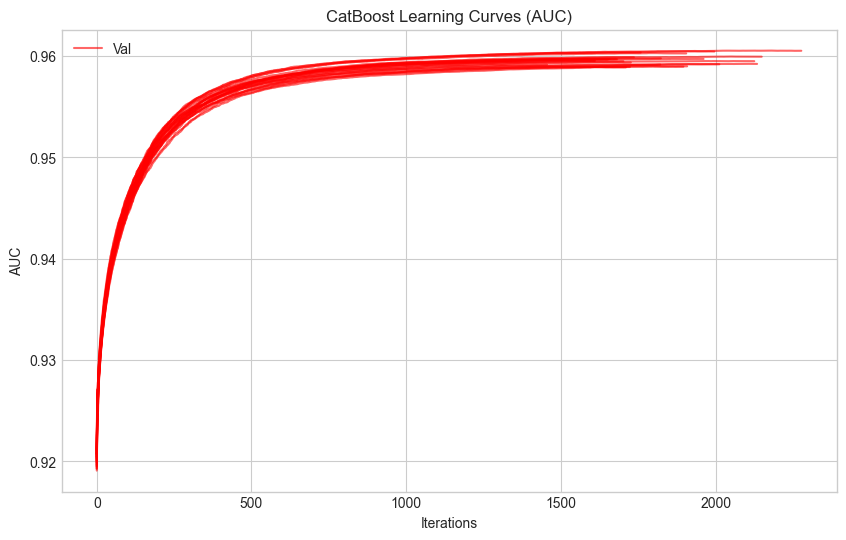

In [9]:
mviz = ModelVisualizer(model_name='CatBoost')

# Map learning metrics to ModelVisualizer expectations
adjusted_evals = []
for res in eval_results:
    # CatBoost puts metrics under 'learn' and 'validation' keys
    adjusted_evals.append({
        'validation_0': res['validation'],
        'validation_1': res['learn']
    })

mviz.plot_learning_curves(adjusted_evals, metric='AUC')

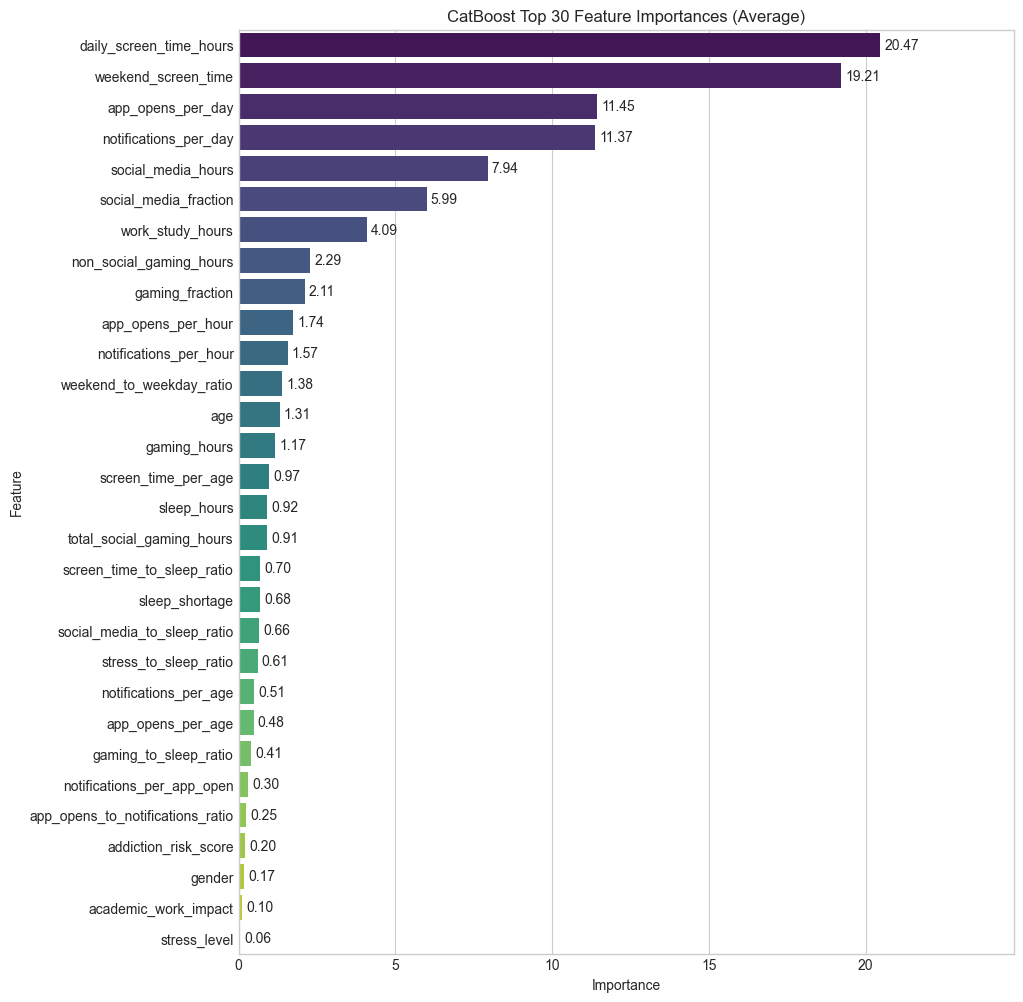

In [10]:
mviz.plot_feature_importance(models, show_values=True)

<Figure size 800x600 with 0 Axes>

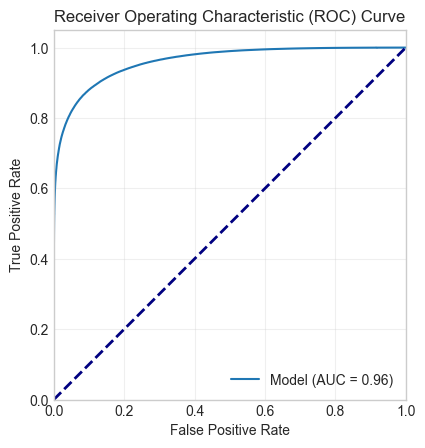

In [11]:
mviz.plot_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask, 1])

Confusion matrix, without normalization


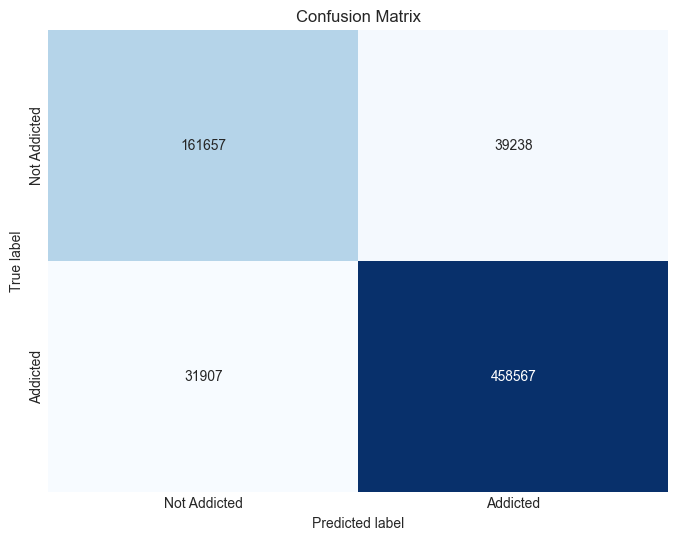

In [12]:
y_pred_class = (oof_probs[:, 1] > 0.5).astype(int)
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=y_pred_class[filled_mask],
    classes=['Not Addicted', 'Addicted']
)

## 8. Export Submission & Predictions

In [13]:
submission_df = setup.read_dataset('submission')
submission_df['addicted_label'] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

Saved submission.csv successfully!


In [14]:
setup.save_probabilities('cb', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved for ensembling:
 - predictions/cb_oof_probs.csv
 - predictions/cb_test_probs.csv
